In [42]:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
from pathlib import Path

In [43]:
def make_speaker(
        ax,
        azim,
        elev,
        r=2,
        da=3,
        de=4,
        dr=0.075,
        first_box=True,
        kwargs_box_update={},
        kwargs_circ0_update={},
        kwargs_circ1_update={}):
    """
    """
    verts_box = []
    for sa in [-1, 1]:
        vert = []
        for (sr, se) in [(-1, 1), (-1, -1), (1, -1), (1, 1)]:
            alpha = azim + sa * da
            polar = 90 - (elev + se * de)
            x = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.cos(np.deg2rad(alpha))
            y = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.sin(np.deg2rad(alpha))
            z = (r + dr * sr) * np.cos(np.deg2rad(polar))
            vert.append([x, y, z])
        verts_box.append(vert)
    for se in [-1, 1]:
        vert = []
        for (sr, sa) in [(-1, 1), (-1, -1), (1, -1), (1, 1)]:
            alpha = azim + sa * da
            polar = 90 - (elev + se * de)
            x = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.cos(np.deg2rad(alpha))
            y = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.sin(np.deg2rad(alpha))
            z = (r + dr * sr) * np.cos(np.deg2rad(polar))
            vert.append([x, y, z])
        verts_box.append(vert)
    for sr in [1, -1]:
        vert = []
        for (sa, se) in [(-1, 1), (-1, -1), (1, -1), (1, 1)]:
            alpha = azim + sa * da
            polar = 90 - (elev + se * de)
            x = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.cos(np.deg2rad(alpha))
            y = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.sin(np.deg2rad(alpha))
            z = (r + dr * sr) * np.cos(np.deg2rad(polar))
            vert.append([x, y, z])
        verts_box.append(vert)
    
    verts_circ0 = []
    vert = []
    for _ in range(0, 360, 15):
        r_circ0 = 1.3
        alpha = azim + sa * (np.sin(np.deg2rad(_)) * r_circ0)
        polar = 90 - (elev - de/4 + se * (np.cos(np.deg2rad(_)) * r_circ0))
        x = (r - dr) * np.sin(np.deg2rad(polar)) * np.cos(np.deg2rad(alpha))
        y = (r - dr) * np.sin(np.deg2rad(polar)) * np.sin(np.deg2rad(alpha))
        z = (r - dr) * np.cos(np.deg2rad(polar))
        vert.append([x, y, z])
    verts_circ0.append(vert)
    verts_circ1 = []
    vert = []
    for _ in range(0, 360, 15):
        r_circ0 = 0.6
        alpha = azim + sa * (np.sin(np.deg2rad(_)) * r_circ0)
        polar = 90 - (elev + de/2 + se * (np.cos(np.deg2rad(_)) * r_circ0))
        x = (r - dr) * np.sin(np.deg2rad(polar)) * np.cos(np.deg2rad(alpha))
        y = (r - dr) * np.sin(np.deg2rad(polar)) * np.sin(np.deg2rad(alpha))
        z = (r - dr) * np.cos(np.deg2rad(polar))
        vert.append([x, y, z])
    verts_circ1.append(vert)
    
    kwargs_box = {
        'fc': 'w',
        'ec': [0.25] * 3,
        'alpha': 1,
        'lw': 1.5,
    }
    kwargs_box.update(kwargs_box_update)
    kwargs_circ0 = {
        'fc': 'w',
        'ec': [0.25] * 3,
        'lw': 1.5,
        'alpha': 1,
    }
    kwargs_circ0.update(kwargs_circ0_update)
    kwargs_circ1 = {
        'fc': 'w',
        'ec': [0.25] * 3,
        'lw': 1.5,
        'alpha': 1,
    }
    kwargs_circ1.update(kwargs_circ1_update)
    if first_box:
        ax.add_collection3d(Poly3DCollection(verts_box, **kwargs_box))
        ax.add_collection3d(Poly3DCollection(verts_circ0, **kwargs_circ0))
        ax.add_collection3d(Poly3DCollection(verts_circ1, **kwargs_circ1))
    else:
        ax.add_collection3d(Poly3DCollection(verts_circ0, **kwargs_circ0))
        ax.add_collection3d(Poly3DCollection(verts_circ1, **kwargs_circ1))
        ax.add_collection3d(Poly3DCollection(verts_box, **kwargs_box))
    return ax

In [44]:
# fig_out_dir = Path("/Users/floof/Library/CloudStorage/GoogleDrive-iangriffith@g.harvard.edu/My Drive/McDermott_Lab/ARO_2024")
fig_out_dir = Path("ARO_2024")

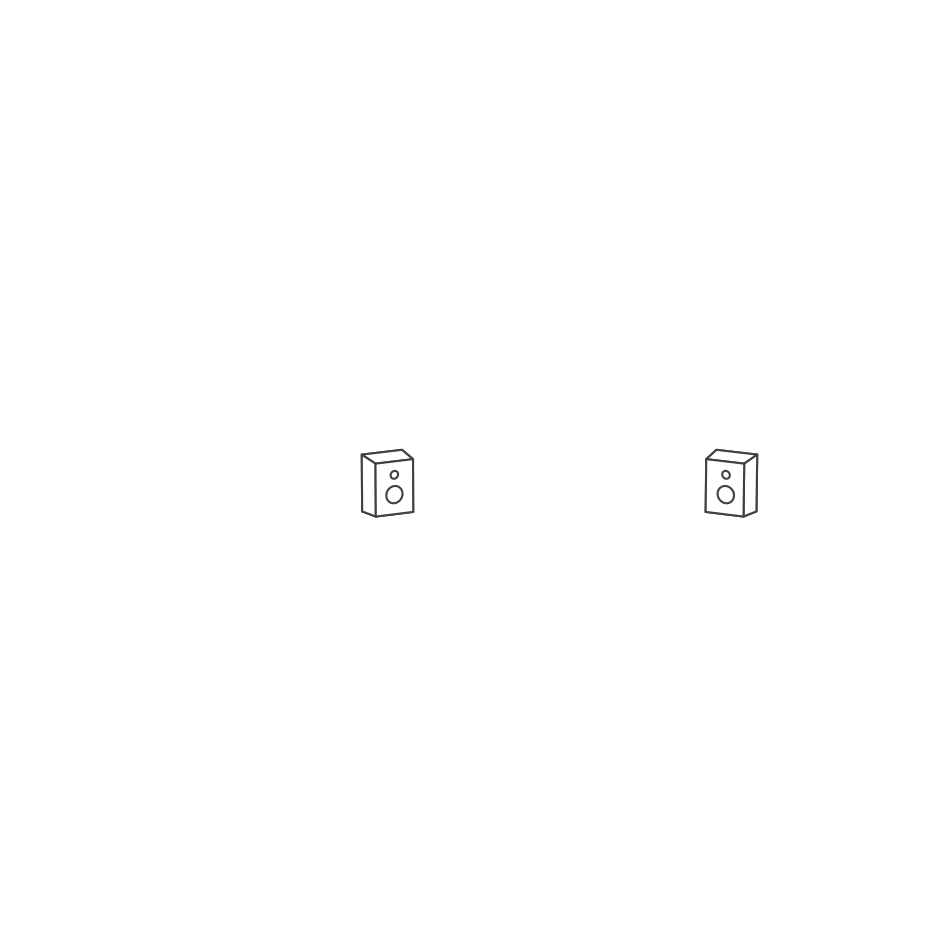

In [32]:
list_azim =   [-20, -70] #np.arange(-90, 91, 10) # [0, -60]
list_elev = [0]#np.arange(-20, 41, 10)

verts_rect = [] # List over speakers
verts_circ = []
verts_circ_sound = []
list_azim_elev_target = [(0, 0)]
list_azim_elev_noise = [
    (30, 10),
    (-90, 0),
    (80, 10),
    (60, -10),
    (70, 30),
    (20, 40),
    (60, 20),
    (10, -10),
    (-80, 20),
    (20, -20),
]

list_azim_elev_target = [(-azim, elev) for (azim, elev) in list_azim_elev_target]
list_azim_elev_noise = [(-azim, elev) for (azim, elev) in list_azim_elev_noise]


subplot_kw={
    'projection':'3d',
    'computed_zorder': False,
}
fig, ax = plt.subplots(subplot_kw=subplot_kw, figsize=plt.figaspect(0.5)*2.0)
itr = 0
for azim in list_azim:
    for elev in list_elev:
        
        kwargs_box_update = {}
        kwargs_circ_update = {}
        if (azim, elev) in list_azim_elev_target:
            kwargs_box_update = {
                'fc': 'k',
                'ec': [0.4] * 3,
            }
            kwargs_circ_update = {
                'fc': 'k',
                'ec': [0.4] * 3,
            }
        elif (azim, elev) in list_azim_elev_noise:
            kwargs_box_update = {
                'fc': [0.6] * 3,
                'ec': [0.1] * 3,
            }
            kwargs_circ_update = {
                'fc': [0.6] * 3,
                'ec': [0.1] * 3,
            }        
        ax = make_speaker(
            ax,
            azim,
            elev,
            first_box = azim < 60,
            kwargs_box_update=kwargs_box_update,
            kwargs_circ0_update=kwargs_circ_update,
            kwargs_circ1_update=kwargs_circ_update)

ax.view_init(15, 135)
ax.set_xlim([0, 1])
ax.set_ylim([-2, 2])
ax.set_zlim([0, 1])
ax.set_box_aspect(aspect=(1, 4, 1))
# ax.set_xlim([-1, 3])
# ax.set_ylim([-2, 2])
# ax.set_zlim([-0, 1])
# ax.set_box_aspect(aspect=(4, 4, 1))
ax.set_axis_off()
plt.tight_layout()

# plt.savefig(fig_out_dir / 'two_speaker_blank.svg', transparent=True)
plt.show()


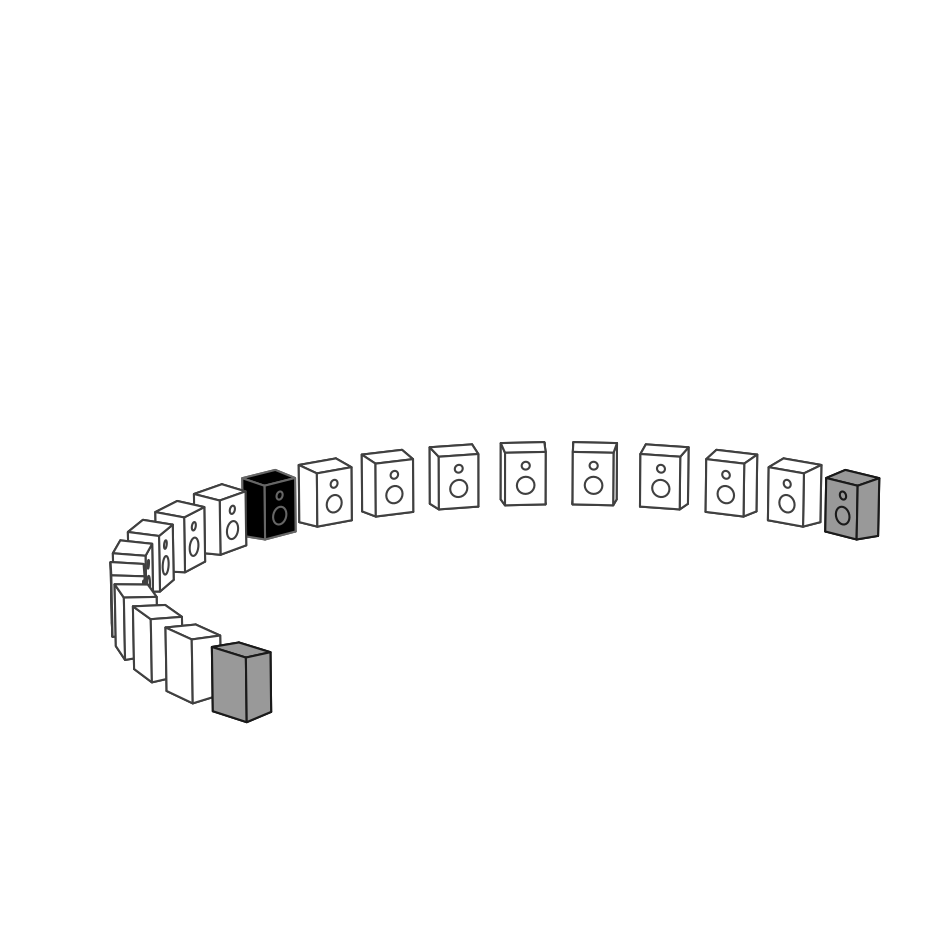

In [46]:
list_azim = np.arange(-90, 91, 10) # [0, -60]
list_elev = [0]#np.arange(-20, 41, 10)

verts_rect = [] # List over speakers
verts_circ = []
verts_circ_sound = []
list_azim_elev_target = [(0, 0)]
list_azim_elev_noise = [(90, 0 ),
                       (-90, 0 ), ]#[
#     (30, 10),
#     (-90, 0),
#     (80, 10),
#     (60, -10),
#     (70, 30),
#     (20, 40),
#     (60, 20),
#     (10, -10),
#     (-80, 20),
#     (20, -20),
# ]

list_azim_elev_target = [(-azim, elev) for (azim, elev) in list_azim_elev_target]
list_azim_elev_noise = [(-azim, elev) for (azim, elev) in list_azim_elev_noise]


subplot_kw={
    'projection':'3d',
    'computed_zorder': False,
}
fig, ax = plt.subplots(subplot_kw=subplot_kw, figsize=plt.figaspect(0.5)*2.0)
itr = 0
for azim in list_azim:
    for elev in list_elev:
        
        kwargs_box_update = {}
        kwargs_circ_update = {}
        if (azim, elev) in list_azim_elev_target:
            kwargs_box_update = {
                'fc': 'k',
                'ec': [0.4] * 3,
            }
            kwargs_circ_update = {
                'fc': 'k',
                'ec': [0.4] * 3,
            }
        elif (azim, elev) in list_azim_elev_noise:
            kwargs_box_update = {
                'fc': [0.6] * 3,
                'ec': [0.1] * 3,
            }
            kwargs_circ_update = {
                'fc': [0.6] * 3,
                'ec': [0.1] * 3,
            }        
        ax = make_speaker(
            ax,
            azim,
            elev,
            first_box = azim < 60,
            kwargs_box_update=kwargs_box_update,
            kwargs_circ0_update=kwargs_circ_update,
            kwargs_circ1_update=kwargs_circ_update)

ax.view_init(15, 135)
ax.set_xlim([0, 1])
ax.set_ylim([-2, 2])
ax.set_zlim([0, 1])
ax.set_box_aspect(aspect=(1, 4, 1))
# ax.set_xlim([-1, 3])
# ax.set_ylim([-2, 2])
# ax.set_zlim([-0, 1])
# ax.set_box_aspect(aspect=(4, 4, 1))
ax.set_axis_off()
plt.tight_layout()

# plt.savefig(fig_out_dir / 'full_azim_array.svg', transparent=True)
plt.show()

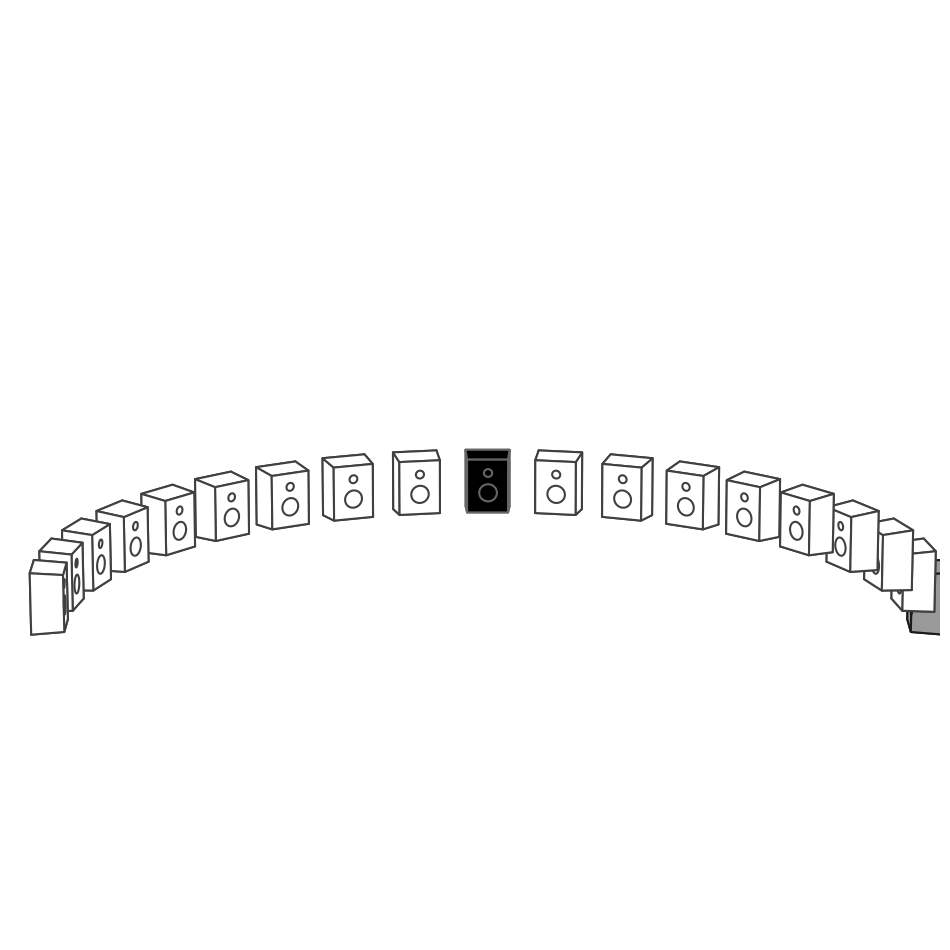

In [35]:
list_azim = np.arange(-90, 91, 10) # [0, -60]
list_elev = [0]#np.arange(-20, 41, 10)

verts_rect = [] # List over speakers
verts_circ = []
verts_circ_sound = []
list_azim_elev_target = [(0, 0)]
list_azim_elev_noise = [(90, 0 )]#[
#     (30, 10),
#     (-90, 0),
#     (80, 10),
#     (60, -10),
#     (70, 30),
#     (20, 40),
#     (60, 20),
#     (10, -10),
#     (-80, 20),
#     (20, -20),
# ]

list_azim_elev_target = [(-azim, elev) for (azim, elev) in list_azim_elev_target]
list_azim_elev_noise = [(-azim, elev) for (azim, elev) in list_azim_elev_noise]


subplot_kw={
    'projection':'3d',
    'computed_zorder': False,
}
fig, ax = plt.subplots(subplot_kw=subplot_kw, figsize=plt.figaspect(0.5)*2.0)
itr = 0
for azim in list_azim:
    for elev in list_elev:
        
        kwargs_box_update = {}
        kwargs_circ_update = {}
        if (azim, elev) in list_azim_elev_target:
            kwargs_box_update = {
                'fc': 'k',
                'ec': [0.4] * 3,
            }
            kwargs_circ_update = {
                'fc': 'k',
                'ec': [0.4] * 3,
            }
        elif (azim, elev) in list_azim_elev_noise:
            kwargs_box_update = {
                'fc': [0.6] * 3,
                'ec': [0.1] * 3,
            }
            kwargs_circ_update = {
                'fc': [0.6] * 3,
                'ec': [0.1] * 3,
            }        
        ax = make_speaker(
            ax,
            azim,
            elev,
            first_box = azim < 60,
            kwargs_box_update=kwargs_box_update,
            kwargs_circ0_update=kwargs_circ_update,
            kwargs_circ1_update=kwargs_circ_update)

ax.view_init(15, 180)
ax.set_xlim([0, 1])
ax.set_ylim([-2, 2])
ax.set_zlim([0, 1])
ax.set_box_aspect(aspect=(1, 4, 1))
# ax.set_xlim([-1, 3])
# ax.set_ylim([-2, 2])
# ax.set_zlim([-0, 1])
# ax.set_box_aspect(aspect=(4, 4, 1))
ax.set_axis_off()
plt.tight_layout()

# plt.savefig(fig_out_dir / 'full_azim_array.svg', transparent=True)
plt.show()

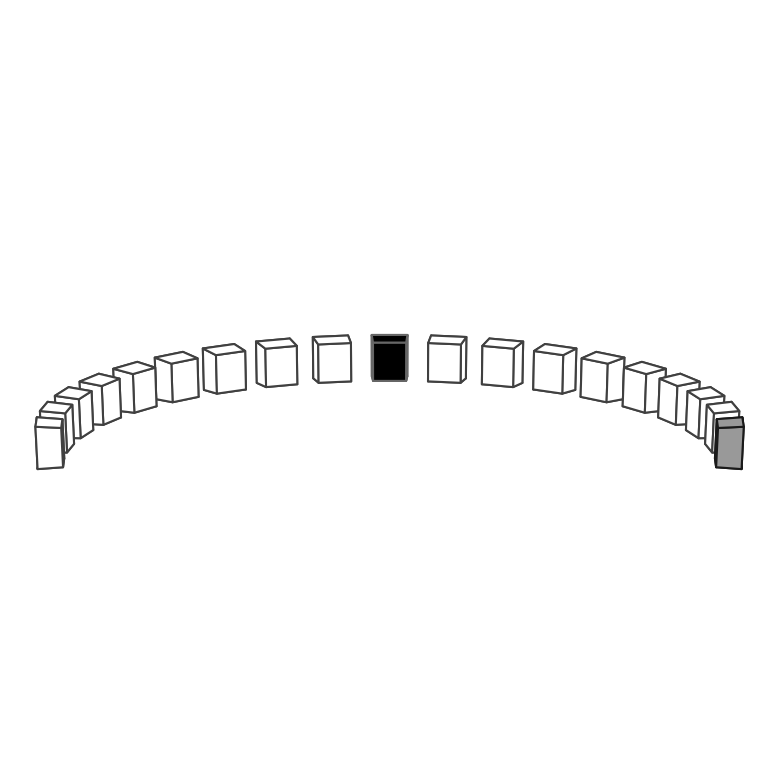

In [39]:
list_azim = np.arange(-90, 91, 10) # [0, -60]
list_elev = [0]#np.arange(-20, 41, 10)

verts_rect = [] # List over speakers
verts_circ = []
verts_circ_sound = []
list_azim_elev_target = [(0, 0)]
list_azim_elev_noise = [(90, 0 )]#[
#     (30, 10),
#     (-90, 0),
#     (80, 10),
#     (60, -10),
#     (70, 30),
#     (20, 40),
#     (60, 20),
#     (10, -10),
#     (-80, 20),
#     (20, -20),
# ]

list_azim_elev_target = [(-azim, elev) for (azim, elev) in list_azim_elev_target]
list_azim_elev_noise = [(-azim, elev) for (azim, elev) in list_azim_elev_noise]


subplot_kw={
    'projection':'3d',
    'computed_zorder': True,
}
fig, ax = plt.subplots(subplot_kw=subplot_kw, figsize=plt.figaspect(0.5)*2.0)
itr = 0
for azim in list_azim:
    for elev in list_elev:
        
        kwargs_box_update = {}
        kwargs_circ_update = {}
        if (azim, elev) in list_azim_elev_target:
            kwargs_box_update = {
                'fc': 'k',
                'ec': [0.4] * 3,
            }
            kwargs_circ_update = {
                'fc': 'k',
                'ec': [0.4] * 3,
            }
        elif (azim, elev) in list_azim_elev_noise:
            kwargs_box_update = {
                'fc': [0.6] * 3,
                'ec': [0.1] * 3,
            }
            kwargs_circ_update = {
                'fc': [0.6] * 3,
                'ec': [0.1] * 3,
            }        
        ax = make_speaker(
            ax,
            azim,
            elev,
            first_box = azim,
            kwargs_box_update=kwargs_box_update,
            kwargs_circ0_update=kwargs_circ_update,
            kwargs_circ1_update=kwargs_circ_update)

ax.view_init(30, 180)
ax.set_xlim([-1, 1])
ax.set_ylim([-2, 2])
ax.set_zlim([0, 1])
ax.set_box_aspect(aspect=(1, 4, 1))
# ax.set_xlim([-1, 3])
# ax.set_ylim([-2, 2])
# ax.set_zlim([-0, 1])
# ax.set_box_aspect(aspect=(4, 4, 1))
ax.set_axis_off()
# plt.tight_layout()

# plt.savefig(fig_out_dir / 'full_azim_array.svg', transparent=True)
plt.show()

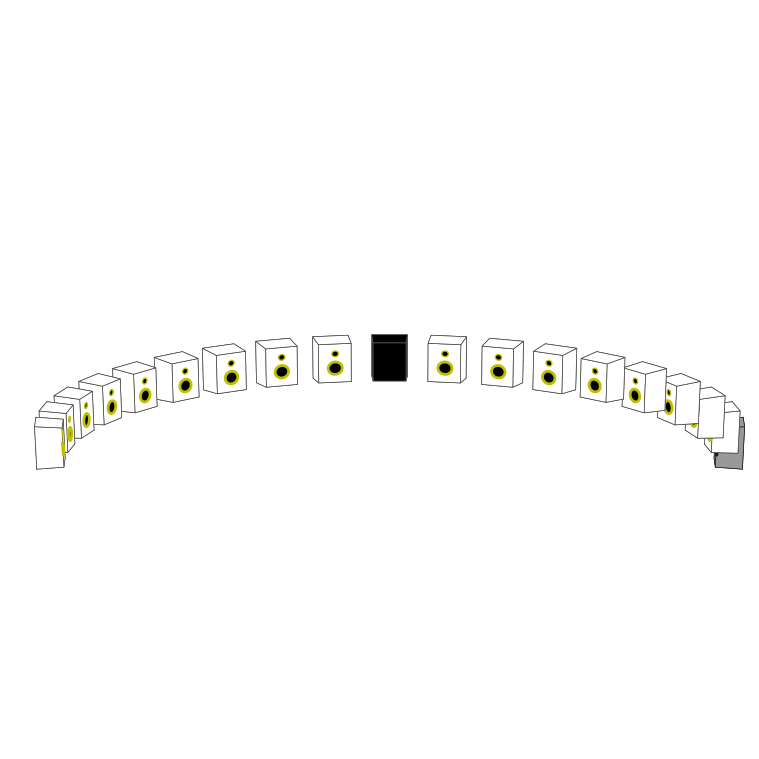

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

def make_speaker(
        ax,
        azim,
        elev,
        r=2,
        da=3,
        de=4,
        dr=0.08,
        first_box=True,
        kwargs_box_update={},
        kwargs_circ0_update={},
        kwargs_circ1_update={}):
    """
    """
    verts_box = []
    for sa in [-1, 1]:
        vert = []
        for (sr, se) in [(-1, 1), (-1, -1), (1, -1), (1, 1)]:
            alpha = azim + sa * da
            polar = 90 - (elev + se * de)
            x = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.cos(np.deg2rad(alpha))
            y = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.sin(np.deg2rad(alpha))
            z = (r + dr * sr) * np.cos(np.deg2rad(polar))
            vert.append([x, y, z])
        verts_box.append(vert)
    for se in [-1, 1]:
        vert = []
        for (sr, sa) in [(-1, 1), (-1, -1), (1, -1), (1, 1)]:
            alpha = azim + sa * da
            polar = 90 - (elev + se * de)
            x = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.cos(np.deg2rad(alpha))
            y = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.sin(np.deg2rad(alpha))
            z = (r + dr * sr) * np.cos(np.deg2rad(polar))
            vert.append([x, y, z])
        verts_box.append(vert)
    for sr in [1, -1]:
        vert = []
        for (sa, se) in [(-1, 1), (-1, -1), (1, -1), (1, 1)]:
            alpha = azim + sa * da
            polar = 90 - (elev + se * de)
            x = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.cos(np.deg2rad(alpha))
            y = (r + dr * sr) * np.sin(np.deg2rad(polar)) * np.sin(np.deg2rad(alpha))
            z = (r + dr * sr) * np.cos(np.deg2rad(polar))
            vert.append([x, y, z])
        verts_box.append(vert)
    
    verts_circ0 = []
    vert = []
    for _ in range(0, 360, 15):
        r_circ0 = 1.3
        alpha = azim + sa * (np.sin(np.deg2rad(_)) * r_circ0)
        polar = 90 - (elev - de/4 + se * (np.cos(np.deg2rad(_)) * r_circ0))
        x = (r - dr) * np.sin(np.deg2rad(polar)) * np.cos(np.deg2rad(alpha))
        y = (r - dr) * np.sin(np.deg2rad(polar)) * np.sin(np.deg2rad(alpha))
        z = (r - dr) * np.cos(np.deg2rad(polar))
        vert.append([x, y, z])
    verts_circ0.append(vert)
    verts_circ1 = []
    vert = []
    for _ in range(0, 360, 15):
        r_circ0 = 0.6
        alpha = azim + sa * (np.sin(np.deg2rad(_)) * r_circ0)
        polar = 90 - (elev + de/2 + se * (np.cos(np.deg2rad(_)) * r_circ0))
        x = (r - dr) * np.sin(np.deg2rad(polar)) * np.cos(np.deg2rad(alpha))
        y = (r - dr) * np.sin(np.deg2rad(polar)) * np.sin(np.deg2rad(alpha))
        z = (r - dr) * np.cos(np.deg2rad(polar))
        vert.append([x, y, z])
    verts_circ1.append(vert)
    
    kwargs_box = {
        'fc': 'w',
        'ec': [0.25] * 3,
        'alpha': 1,
        'lw': 0.5,
    }
    kwargs_box.update(kwargs_box_update)
    kwargs_circ0 = {
        'fc': 'k',
        'ec': 'y',
        'lw': 2,
        'alpha': 1,
    }
    kwargs_circ0.update(kwargs_circ0_update)
    kwargs_circ1 = {
        'fc': 'k',
        'ec': 'y',
        'lw': 1,
        'alpha': 1,
    }
    kwargs_circ1.update(kwargs_circ1_update)
    if first_box:
        ax.add_collection3d(Poly3DCollection(verts_box, **kwargs_box))
        ax.add_collection3d(Poly3DCollection(verts_circ0, **kwargs_circ0))
        ax.add_collection3d(Poly3DCollection(verts_circ1, **kwargs_circ1))
    else:
        ax.add_collection3d(Poly3DCollection(verts_circ0, **kwargs_circ0))
        ax.add_collection3d(Poly3DCollection(verts_circ1, **kwargs_circ1))
        ax.add_collection3d(Poly3DCollection(verts_box, **kwargs_box))
    return ax

list_azim = np.arange(-90, 91, 10) # [0, -60]
list_elev = [0]#np.arange(-20, 41, 10)

verts_rect = [] # List over speakers
verts_circ = []
verts_circ_sound = []
list_azim_elev_target = [(0, 0)]
list_azim_elev_noise = [(90, 0 )]#[
#     (30, 10),
#     (-90, 0),
#     (80, 10),
#     (60, -10),
#     (70, 30),
#     (20, 40),
#     (60, 20),
#     (10, -10),
#     (-80, 20),
#     (20, -20),
# ]

list_azim_elev_target = [(-azim, elev) for (azim, elev) in list_azim_elev_target]
list_azim_elev_noise = [(-azim, elev) for (azim, elev) in list_azim_elev_noise]


subplot_kw={
    'projection':'3d',
    'computed_zorder': False,
}
fig, ax = plt.subplots(subplot_kw=subplot_kw, figsize=plt.figaspect(0.5)*2.0)
itr = 0
for azim in list_azim:
    for elev in list_elev:
        
        kwargs_box_update = {}
        kwargs_circ_update = {}
        if (azim, elev) in list_azim_elev_target:
            kwargs_box_update = {
                'fc': 'k',
                'ec': [0.4] * 3,
            }
            kwargs_circ_update = {
                'fc': 'k',
                'ec': [0.4] * 3,
            }
        elif (azim, elev) in list_azim_elev_noise:
            kwargs_box_update = {
                'fc': [0.6] * 3,
                'ec': [0.1] * 3,
            }
            kwargs_circ_update = {
                'fc': [0.6] * 3,
                'ec': [0.1] * 3,
            }        
        ax = make_speaker(
            ax,
            azim,
            elev,
            first_box = azim,
            kwargs_box_update=kwargs_box_update,
            kwargs_circ0_update=kwargs_circ_update,
            kwargs_circ1_update=kwargs_circ_update)

ax.view_init(30, 180)
ax.set_xlim([-1, 1])
ax.set_ylim([-2, 2])
ax.set_zlim([0, 1])
ax.set_box_aspect(aspect=(1, 4, 1))
ax.set_axis_off()
plt.show()